# Cifar-10 and Convolutional Neural Network 

This notebook is part of a Cifar-10 assignment for the Neural Network Project course at Metropolia University of Applied Sciences. The notebook demonstrates how to build and train a convolutional neural network (CNN) for image classification using the CIFAR-10 dataset. The CIFAR-10 dataset consists of 60 000 32x32 color images in 10 classes, with 6000 images per class. The aim is to achieve a test accuracy of at least 50% using a convolutional neural network. The cifar10_fcn.ipynb notebook contains a fully connected neural network (FCN) implementation for the same dataset so that these two can be compared. 

In [17]:
import keras
from keras import layers, datasets, utils
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

# Load the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

# Preprocess: normalization and reshaping
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatten labels and one-hot encode
y_train = utils.to_categorical(y_train.reshape(-1), 10)
y_test = utils.to_categorical(y_test.reshape(-1), 10)

print("X_train shape:", X_train.shape)
print(X_train.shape[0], "train samples")
print(X_test.shape[0], "test samples")

Training data shape: (50000, 32, 32, 3), Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3), Test labels shape: (10000, 1)
X_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


This analysis will use one method to create the CNN model, but with different architectures. First a baseline model will be created with one convolutional layer (activation relu), one max pooling layer and one fully connected layer (softmax). After that, the following experiments will be conducted:

- Varying the batch size
- Varying the depth of the network (number of convolutional layers)
- Adding dropout layers
- Using batch normalization

At the end of each experiment, the training and validation loss will be plotted to compare the results. After all experiments a table will be created to summarize the results.

The typical epoch amount for CNN is 20-50 for a CIFAR-10 project and that is why all models in the comparison will be trained for 40 epochs to ensure that the models have enought time to learn but the matter of overfitting should be considered when choosing the final model to make predictions with. The curves for each experiment should be analyzed to see if the model starts overfitting at some point and if in fact the model would have been better with a lower epoch amount.

In [18]:
def create_cnn(num_conv_layers=2, base_filters=32, dropout_rate=0.5, use_batchnorm=False):
    inputs = keras.Input(shape=(32, 32, 3))
    x = inputs

    filters = base_filters

    for i in range(num_conv_layers):
        x = keras.layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
        
        if use_batchnorm:
            x = keras.layers.BatchNormalization()(x)
        
        # Only apply pooling if the spatial dimensions are > 1
        h, w = x.shape[1], x.shape[2]
        if h > 1 and w > 1:
            x = keras.layers.MaxPooling2D((2, 2), padding='same')(x)
        
        filters *= 2  # increase depth

    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(dropout_rate)(x)
    outputs = keras.layers.Dense(10, activation='softmax')(x)

    return keras.Model(inputs, outputs)

In [19]:
# Storage for all experiments
all_results = []
all_histories = {}

def log_results(name, model, history, train_time, test_acc, batch_size):
    all_results.append({
        "Model": name,
        "Test Accuracy": test_acc,
        "Train Time (s)": train_time,
        "Parameters": model.count_params(),
        "Batch Size": batch_size
    })
    all_histories[name] = history

In [20]:
# Method for plotting loss and accuracy
def plot_training_curves(log_dict, metric="loss", title="Training Curves"):
    plt.figure(figsize=(8,5))
    
    for name, history in log_dict.items():
        if metric in history.history:
            plt.plot(history.history[metric], label=f"{name} train" if "val" not in metric else f"{name} val")
        # Also plot corresponding validation curve if metric is 'loss' or 'accuracy'
        if "val" not in metric:
            val_metric = f"val_{metric}"
            if val_metric in history.history:
                plt.plot(history.history[val_metric], linestyle='--', label=f"{name} val")
    
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel(metric.replace("_", " ").title())
    plt.legend()
    plt.grid(True)
    plt.show()

In [21]:
# Create baseline model
name = "baseline_b4"

model = create_cnn(num_conv_layers=2, dropout_rate=0.5, use_batchnorm=False)

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

start = time.time()

history = model.fit(
    X_train, y_train,
    batch_size=4,
    epochs=40,
    validation_split=0.1,
    verbose=1
)

train_time = time.time() - start
_, acc = model.evaluate(X_test, y_test, verbose=0)

log_results(name, model, history, train_time, acc, batch_size=4)

Epoch 1/40
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.4622 - loss: 1.4961 - val_accuracy: 0.5656 - val_loss: 1.2415
Epoch 2/40
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.5711 - loss: 1.2221 - val_accuracy: 0.5958 - val_loss: 1.1697
Epoch 3/40
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.6011 - loss: 1.1325 - val_accuracy: 0.6552 - val_loss: 0.9860
Epoch 4/40
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.6212 - loss: 1.0777 - val_accuracy: 0.6620 - val_loss: 0.9750
Epoch 5/40
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.6319 - loss: 1.0548 - val_accuracy: 0.6844 - val_loss: 0.9208
Epoch 6/40
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.6384 - loss: 1.0340 - val_accuracy: 0.6680 - val_loss: 0.9681
Epoch 7/40
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.6467 - loss: 1.0122 - val_accuracy: 0.6574 - val_loss: 0.9833
Epoch 8/40
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 

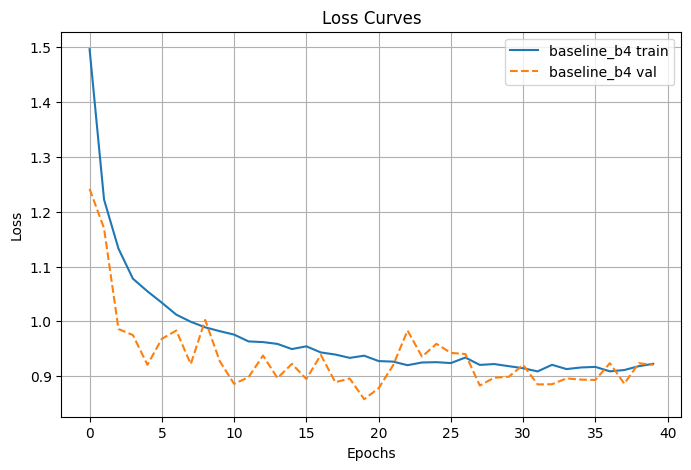

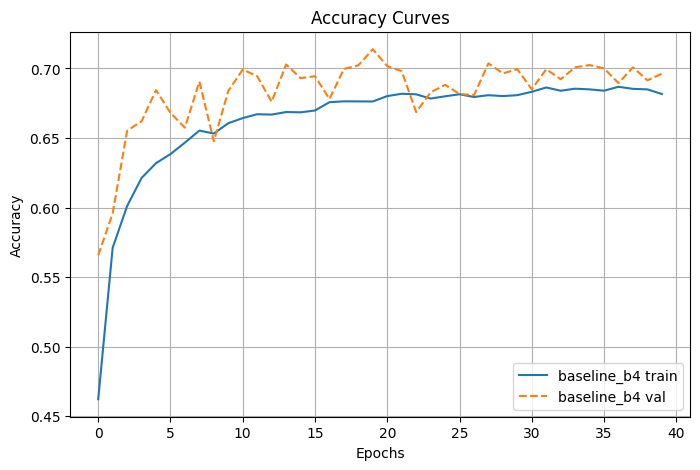

In [22]:
plot_training_curves(all_histories, metric="loss", title="Loss Curves")
plot_training_curves(all_histories, metric="accuracy", title="Accuracy Curves")

Based on these curves for the baseline model, overfitting starts somewhere after 15 epochs. At 15 epochs the test accuracy is about 0.7 which is already quite good. In the next section the batch size will be varied to see if the model can achieve better results with a different batch size and when the overfitting starts with different batch sizes. Batch size means the number of samples run through the network before the weights are updated. A smaller batch size means more updates and a larger batch size means less updates. 

Epoch 1/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.4576 - loss: 1.5235 - val_accuracy: 0.5738 - val_loss: 1.2270
Epoch 2/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5745 - loss: 1.2093 - val_accuracy: 0.6140 - val_loss: 1.1156
Epoch 3/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6176 - loss: 1.0960 - val_accuracy: 0.6710 - val_loss: 0.9711
Epoch 4/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6386 - loss: 1.0351 - val_accuracy: 0.6706 - val_loss: 0.9560
Epoch 5/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6591 - loss: 0.9831 - val_accuracy: 0.6920 - val_loss: 0.9174
Epoch 6/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6665 - loss: 0.9515 - val_accuracy: 0.7056 - val_loss: 0.8701
Epoch 7/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6775 - loss: 0.9189 - val_accuracy: 0.7054 - val_loss: 0.8751
Epoch 8/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6879 - loss: 0

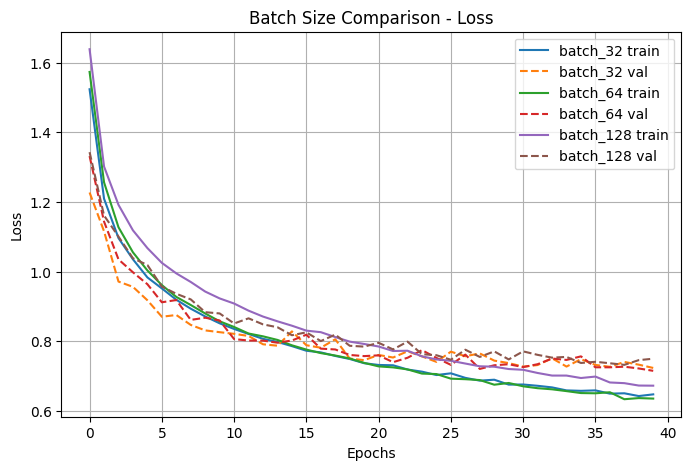

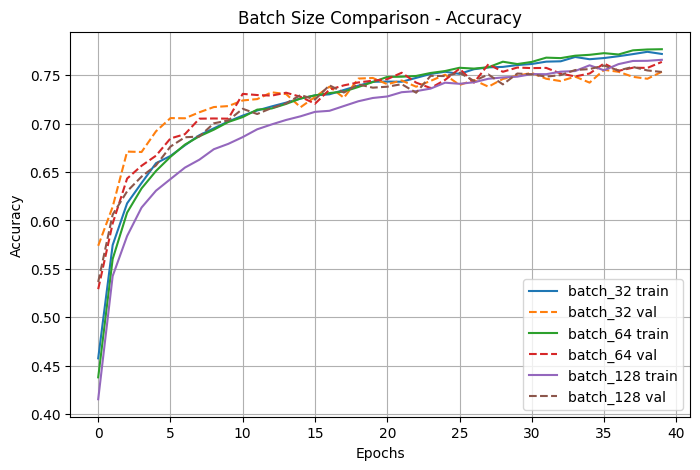

In [23]:
# Batch size experiments
batch_sizes = [32, 64, 128]
batch_history = {}
for b in batch_sizes:
    name = f"batch_{b}"

    model = create_cnn(num_conv_layers=2, dropout_rate=0.5, use_batchnorm=False)
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

    start = time.time()

    history = model.fit(
        X_train, y_train,
        batch_size=b,
        epochs=40,
        validation_split=0.1,
        verbose=1
    )

    train_time = time.time() - start
    _, acc = model.evaluate(X_test, y_test, verbose=0)

    log_results(name, model, history, train_time, acc, batch_size=b)

    batch_history[name] = history

plot_training_curves(batch_history, metric="loss", title="Batch Size Comparison - Loss")
plot_training_curves(batch_history, metric="accuracy", title="Batch Size Comparison - Accuracy")

In [36]:
comparison_df = pd.DataFrame(batch_history.keys(), columns=["Model"])
comparison_df["Test Accuracy"] = [history.history['val_accuracy'][-1] for history in batch_history.values()]
comparison_df["Train Time (s)"] = [all_results[i]["Train Time (s)"] for i in range(len(all_results)) if all_results[i]["Model"] in batch_history.keys()]
print(comparison_df)

       Model  Test Accuracy  Train Time (s)
0   batch_32         0.7534      472.658875
1   batch_64         0.7636      422.313018
2  batch_128         0.7532     1082.359577


The chosen batch sizes did not differ that much in terms of test accuracy. The best results were obtained with a batch size of 64 which starts to overfit somewhere after 15 epochs. For the final model a batch size of 64 will be used.

Next the depth of the network will be varied. The depth of the network means the number of convolutional layers. 

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4381 - loss: 1.5728 - val_accuracy: 0.5500 - val_loss: 1.2881
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5640 - loss: 1.2452 - val_accuracy: 0.5982 - val_loss: 1.1715
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.6081 - loss: 1.1257 - val_accuracy: 0.6532 - val_loss: 1.0198
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.6367 - loss: 1.0491 - val_accuracy: 0.6738 - val_loss: 0.9685
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6498 - loss: 1.0036 - val_accuracy: 0.6904 - val_loss: 0.9263
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6671 - loss: 0.9628 - val_accuracy: 0.6954 - val_loss: 0.9089
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6808 - loss: 0.9238 - val_accuracy: 0.7056 - val_loss: 0.8820
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6880 - loss: 0.8998 - 

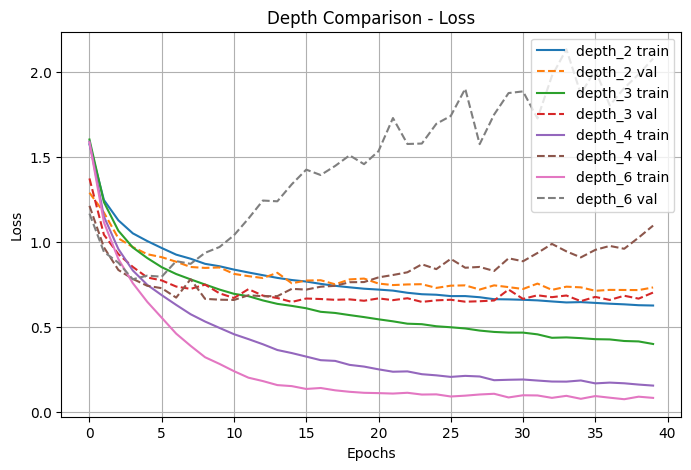

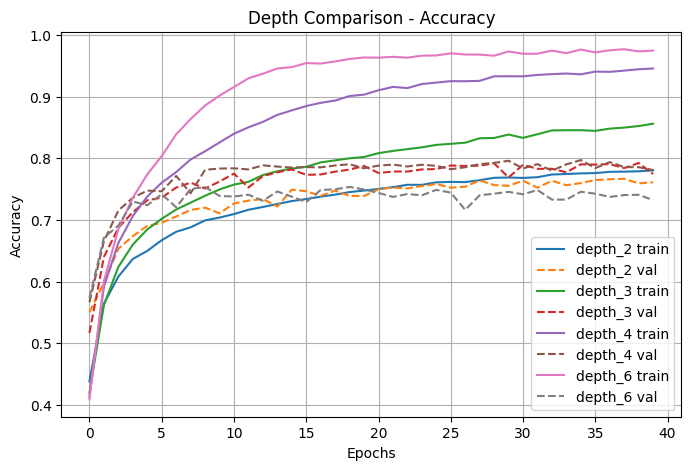

In [24]:
# Cell depth experiments
depths = [2, 3, 4, 6]
depth_history = {}
for d in depths:
    name = f"depth_{d}"
    
    model = create_cnn(num_conv_layers=d, dropout_rate=0.5, use_batchnorm=False)
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

    start = time.time()

    history = model.fit(
        X_train, y_train,
        batch_size=64,  # use best from previous step
        epochs=40,
        validation_split=0.1,
        verbose=1
    )

    train_time = time.time() - start
    _, acc = model.evaluate(X_test, y_test, verbose=0)

    log_results(name, model, history, train_time, acc, batch_size=64)

    depth_history[name] = history
plot_training_curves(depth_history, metric="loss", title="Depth Comparison - Loss")
plot_training_curves(depth_history, metric="accuracy", title="Depth Comparison - Accuracy")

In [39]:
depth_comparison_df = pd.DataFrame(depth_history.keys(), columns=["Model"])
depth_comparison_df["Test Accuracy"] = [history.history['val_accuracy'][-1] for history in depth_history.values()]
depth_comparison_df["Train Time (s)"] = [all_results[i]["Train Time (s)"] for i in range(len(all_results)) if all_results[i]["Model"] in depth_history.keys()]
print(depth_comparison_df)

     Model  Test Accuracy  Train Time (s)
0  depth_2         0.7612      424.800149
1  depth_3         0.7746      577.328001
2  depth_4         0.7810      774.666332
3  depth_6         0.7322     9020.855312


As seen on the loss curves, the bigger the depth of the network, the sooner it starts to overfit. It seems that the best results were obtained with a depth of 2 or 3 convolutional layers. With 3 layers the overfitting start a bit earlier, but the test accuracy is better if you choose a lower epoch amount. The final model could be tested with both 2 and 3 convolutional layers to see which one performs better with a lower epoch amount and other hyperparameters.

Next the dropout rate will be varied. Dropout is a technique used to prevent overfitting by randomly setting some of the activations to zero during training. That means that the model will not rely too much on any particular feature and will be more robust. The dropout rate is the percentage of activations that are set to zero. A dropout rate of 0.5 means that half of the activations are set to zero during training.

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.4693 - loss: 1.4795 - val_accuracy: 0.5776 - val_loss: 1.1948
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6244 - loss: 1.0703 - val_accuracy: 0.6684 - val_loss: 0.9559
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6837 - loss: 0.9128 - val_accuracy: 0.7108 - val_loss: 0.8487
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7240 - loss: 0.8015 - val_accuracy: 0.7290 - val_loss: 0.8249
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7527 - loss: 0.7208 - val_accuracy: 0.7370 - val_loss: 0.7844
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7734 - loss: 0.6582 - val_accuracy: 0.7410 - val_loss: 0.7902
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7935 - loss: 0.6018 - val_accuracy: 0.7506 - val_loss: 0.7668
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8113 - loss: 0.5484 - 

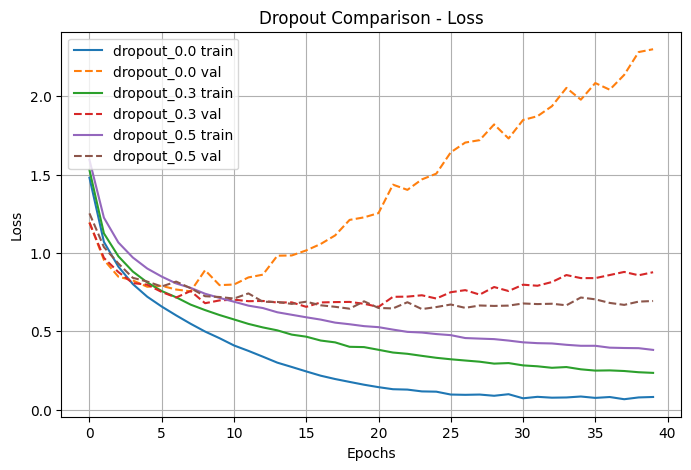

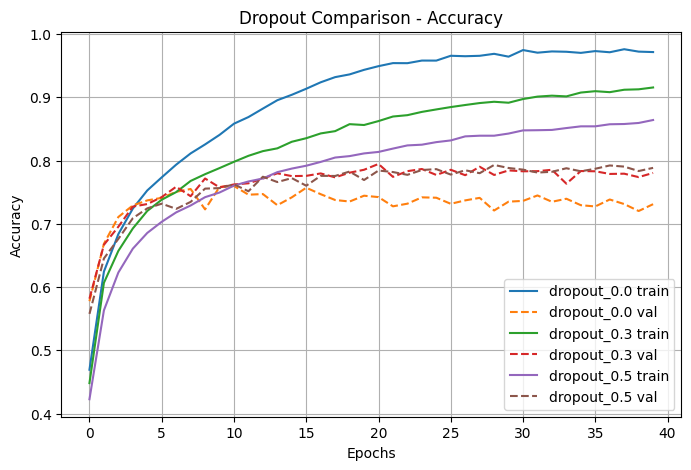

In [25]:
# Dropout experiments
dropouts = [0.0, 0.3, 0.5]
dropout_history = {}
for d in dropouts:
    name = f"dropout_{d}"
    
    model = create_cnn(num_conv_layers=3, dropout_rate=d, use_batchnorm=False)
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

    start = time.time()

    history = model.fit(
        X_train, y_train,
        batch_size=64,
        epochs=40,
        validation_split=0.1,
        verbose=1
    )

    train_time = time.time() - start
    _, acc = model.evaluate(X_test, y_test, verbose=0)

    log_results(name, model, history, train_time, acc, batch_size=64)

    dropout_history[name] = history

plot_training_curves(dropout_history, metric="loss", title="Dropout Comparison - Loss")
plot_training_curves(dropout_history, metric="accuracy", title="Dropout Comparison - Accuracy")

In [40]:
dropout_comparison_df = pd.DataFrame(dropout_history.keys(), columns=["Model"])
dropout_comparison_df["Test Accuracy"] = [history.history['val_accuracy'][-1] for history in dropout_history.values()]
dropout_comparison_df["Train Time (s)"] = [all_results[i]["Train Time (s)"] for i in range(len(all_results)) if all_results[i]["Model"] in dropout_history.keys()]
print(dropout_comparison_df)

         Model  Test Accuracy  Train Time (s)
0  dropout_0.0         0.7310      571.460428
1  dropout_0.3         0.7804      600.018017
2  dropout_0.5         0.7884      604.124517


As seen on the curves, without dropout the model starts to overfit the earliest. The drop out rates of 0.3 and 0.5 seem to perform quite similarly both in terms of test accuracy and overfitting. The 0.5 dropout rate seems to start overfitting a bit later so it could be a better choice for the final model with overfitting at about after 10 epochs.

Next the batch normalization will be tested. Batch normalization is a technique used to improve the training of deep neural networks by normalizing the activations of each layer by the mean and standard deviation of the batch. This can help with overfitting and other training issues. 

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.4365 - loss: 1.5573 - val_accuracy: 0.5758 - val_loss: 1.2108
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.5838 - loss: 1.1711 - val_accuracy: 0.6478 - val_loss: 1.0252
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.6472 - loss: 1.0068 - val_accuracy: 0.6838 - val_loss: 0.9389
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6823 - loss: 0.9088 - val_accuracy: 0.6954 - val_loss: 0.9035
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.7051 - loss: 0.8493 - val_accuracy: 0.7264 - val_loss: 0.7929
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.7245 - loss: 0.7916 - val_accuracy: 0.7492 - val_loss: 0.7497
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.7430 - loss: 0.7425 - val_accuracy: 0.7502 - val_loss: 0.7440
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.7536 - loss: 0.7080 - 

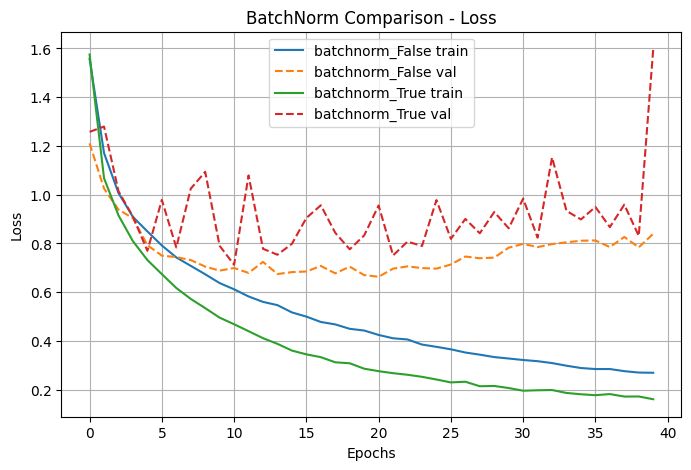

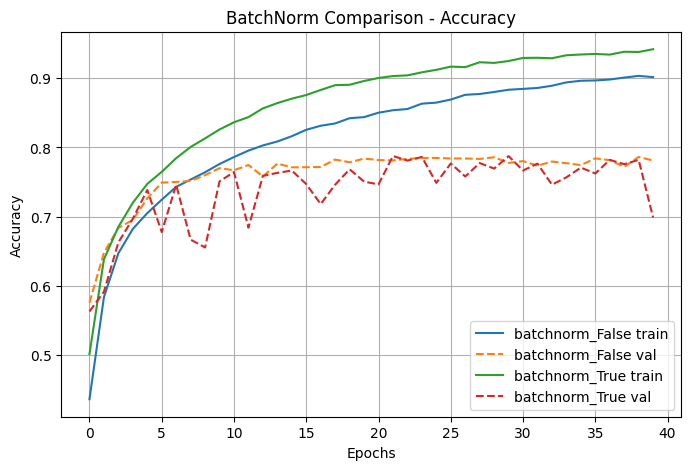

In [26]:
# Batch norm experiments
options = [False, True]
batch_norm_history = {}
for bn in options:
    name = f"batchnorm_{bn}"
    
    model = create_cnn(num_conv_layers=3, dropout_rate=0.3, use_batchnorm=bn)
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

    start = time.time()

    history = model.fit(
        X_train, y_train,
        batch_size=64,
        epochs=40,
        validation_split=0.1,
        verbose=1
    )

    train_time = time.time() - start
    _, acc = model.evaluate(X_test, y_test, verbose=0)

    log_results(name, model, history, train_time, acc, batch_size=64)

    batch_norm_history[name] = history

plot_training_curves(batch_norm_history, metric="loss", title="BatchNorm Comparison - Loss")
plot_training_curves(batch_norm_history, metric="accuracy", title="BatchNorm Comparison - Accuracy")

In [41]:
batch_norm_comparison_df = pd.DataFrame(batch_norm_history.keys(), columns=["Model"])
batch_norm_comparison_df["Test Accuracy"] = [history.history['val_accuracy'][-1] for history in batch_norm_history.values()]
batch_norm_comparison_df["Train Time (s)"] = [all_results[i]["Train Time (s)"] for i in range(len(all_results)) if all_results[i]["Model"] in batch_norm_history.keys()]
print(batch_norm_comparison_df)

             Model  Test Accuracy  Train Time (s)
0  batchnorm_False         0.7810      624.232037
1   batchnorm_True         0.6988     1366.191313


The batch normalization does not seem to improve the model. The training time is also significantly longer. The final model will be created without batch normalization as it seems to be more stable than the model with batch normalization.

In [27]:
df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values(by="Test Accuracy", ascending=False)

print(df_results)

              Model  Test Accuracy  Train Time (s)  Parameters  Batch Size
10      dropout_0.5         0.7832      604.124517      113738          64
6           depth_4         0.7723      774.666332      398666          64
5           depth_3         0.7667      577.328001      113738          64
9       dropout_0.3         0.7590      600.018017      113738          64
4           depth_2         0.7568      424.800149       60362          64
11  batchnorm_False         0.7545      624.232037      113738          64
1          batch_32         0.7500      472.658875       60362          32
2          batch_64         0.7492      422.313018       60362          64
3         batch_128         0.7396     1082.359577       60362         128
7           depth_6         0.7213     9020.855312     6298442          64
8       dropout_0.0         0.7121      571.460428      113738          64
12   batchnorm_True         0.6915     1366.191313      114634          64
0       baseline_b4      

The final model will be created with a batch size of 64, a depth of 2 or 3 convolutional layers, a dropout rate of 0.5 and no batch normalization. The final model will be trained for 15 epochs to avoid overfitting and to achieve the best test accuracy. 

In [70]:
final_configs = [
    {"name": "final_2conv", "num_conv_layers": 2},
    {"name": "final_3conv", "num_conv_layers": 3},
]

final_histories = {}
final_test_accuracies = {}
final_train_times = {}
final_num_params = {}

for config in final_configs:
    print(f"\nTraining {config['name']}...")

    model = create_cnn(
        num_conv_layers=config["num_conv_layers"],
        dropout_rate=0.5,
        use_batchnorm=False
    )

    model.compile(
        loss="categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )

    final_num_params[config["name"]] = model.count_params()

    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        batch_size=64,
        epochs=50,
        validation_split=0.1,
        verbose=1
    )

    train_time = time.time() - start_time

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    final_histories[config["name"]] = history
    final_test_accuracies[config["name"]] = acc
    final_train_times[config["name"]] = train_time

    print(f"{config['name']} - Test Accuracy: {acc:.4f}, "
          f"Params: {final_num_params[config['name']]}, "
          f"Time: {train_time:.2f}s")


Training final_2conv...
Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4325 - loss: 1.5968 - val_accuracy: 0.5446 - val_loss: 1.3042
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5540 - loss: 1.2708 - val_accuracy: 0.6016 - val_loss: 1.1527
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5998 - loss: 1.1462 - val_accuracy: 0.6584 - val_loss: 1.0238
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6293 - loss: 1.0661 - val_accuracy: 0.6670 - val_loss: 0.9881
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6486 - loss: 1.0104 - val_accuracy: 0.6856 - val_loss: 0.9321
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6602 - loss: 0.9783 - val_accuracy: 0.6912 - val_loss: 0.9042
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6715 - loss: 0.9428 - val_accuracy: 0.7050 - val_loss: 0.8809
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy:

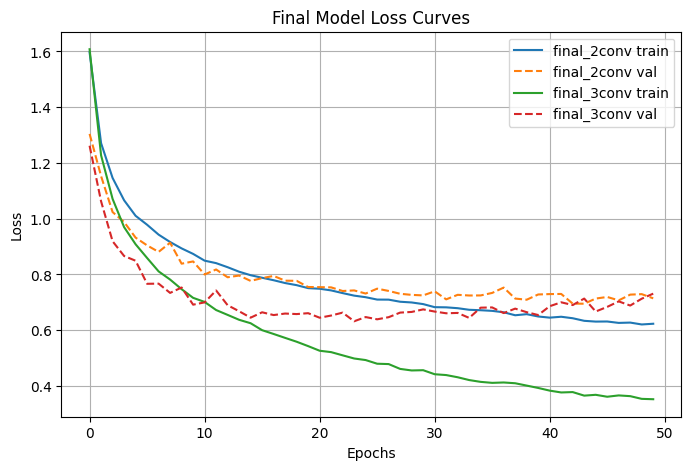

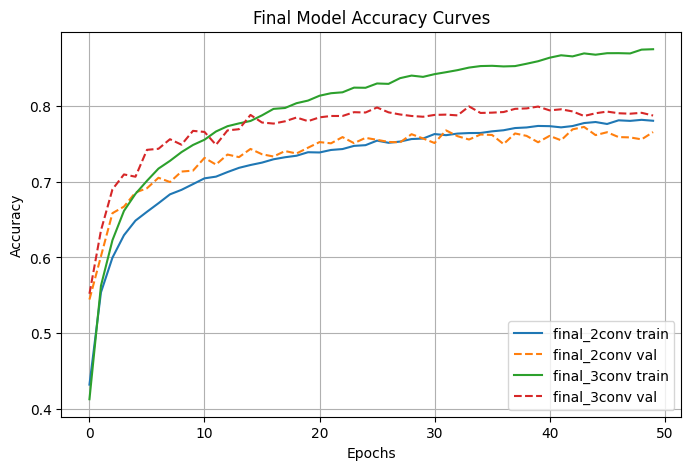

In [71]:
plot_training_curves(final_histories, metric="loss", title="Final Model Loss Curves")
plot_training_curves(final_histories, metric="accuracy", title="Final Model Accuracy Curves")

In [72]:
final_results = pd.DataFrame(final_histories.keys(), columns=["Model"])
final_results["Test Accuracy"] = [final_test_accuracies[name] for name in final_histories.keys()]
final_results["Train Time (s)"] = [final_train_times[name] for name in final_histories.keys()]
final_results["Parameters"] = [final_num_params[name] for name in final_histories.keys()]
print(final_results)

         Model  Test Accuracy  Train Time (s)  Parameters
0  final_2conv         0.7537      568.756327       60362
1  final_3conv         0.7669      797.713325      113738


The 3 layer model seems to perform better if you choose a lower epoch amount. At 10 epochs the 3 layer model starts overfitting, but at that point the test accuracy is still better than the 2 layer model. The final model will be created with 3 convolutional layers, a batch size of 64, a dropout rate of 0.5 and no batch normalization. The final model will be trained for 10 epochs to avoid overfitting and to achieve the best test accuracy. Let´s also add data augmentation to the final model to see if it can improve the results. Data augmentation is a technique used to increase the amount of data by creating new data from the existing data. This can be done by applying random transformations to the images such as rotation, flipping, zooming, etc. This can help with overfitting and improve the generalization of the model. The epoch amount can be increased to 15 to see if the model can achieve better results with data augmentation.

In [73]:
final_name = "final_3conv_augmented"

# Augmentation block
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

# Build model manually
inputs = keras.Input(shape=(32, 32, 3))

x = data_augmentation(inputs)  # 👈 augmentation added here

# Conv block 1
x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)

# Conv block 2
x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)

# Conv block 3
x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)

# Classifier
x = layers.Flatten()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs, outputs)

# Compile
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_47 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_110 (Conv2D)             │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_109               │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_111 (Conv2D)             │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_110               │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_112 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_111               │ (None, 4, 4, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_40 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,738 (444.29 KB)

 Trainable params: 113,738 (444.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start_time = time.time()

history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=30,
    validation_split=0.1,
    verbose=1
)

train_time = time.time() - start_time

loss, acc = model.evaluate(X_test, y_test, verbose=0)

print(f"\nAugmented Model - Test Accuracy: {acc:.4f}")
print(f"Training Time: {train_time:.2f}s")
log_results(final_name, model, history, train_time, acc, batch_size=64)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.4287 - loss: 1.5831 - val_accuracy: 0.4952 - val_loss: 1.4350
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.5574 - loss: 1.2466 - val_accuracy: 0.5956 - val_loss: 1.1704
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6106 - loss: 1.1084 - val_accuracy: 0.6020 - val_loss: 1.1943
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6418 - loss: 1.0260 - val_accuracy: 0.6740 - val_loss: 0.9536
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6611 - loss: 0.9716 - val_accuracy: 0.7088 - val_loss: 0.8605
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6791 - loss: 0.9241 - val_accuracy: 0.7044 - val_loss: 0.8564
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6906 - loss: 0.8898 - val_accuracy: 0.7208 - val_loss: 0.8023
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.6996 - loss: 0.8598 - 

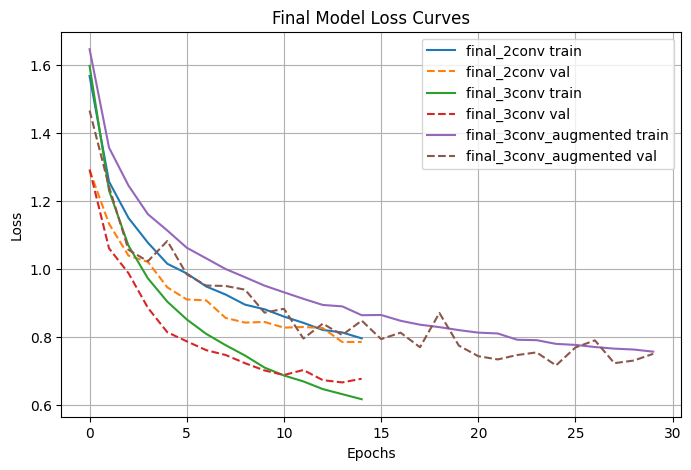

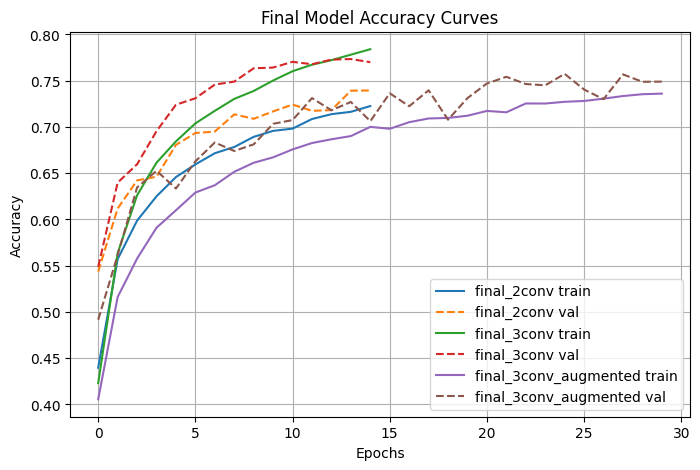

Test Accuracy: 0.7386, Training Time: 508.58s, Parameters: 113738


In [ ]:
final_histories["final_3conv_augmented"] = history
plot_training_curves(final_histories, metric="loss", title="Final Model Loss Curves")
plot_training_curves(final_histories, metric="accuracy", title="Final Model Accuracy Curves")
print(f"Test Accuracy: {acc:.4f}, Training Time: {train_time:.2f}s, Parameters: {model.count_params()}")

Test Accuracy: 0.7445
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


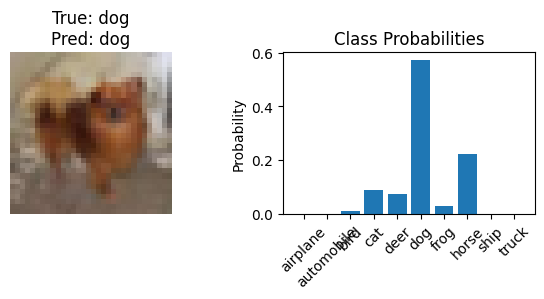

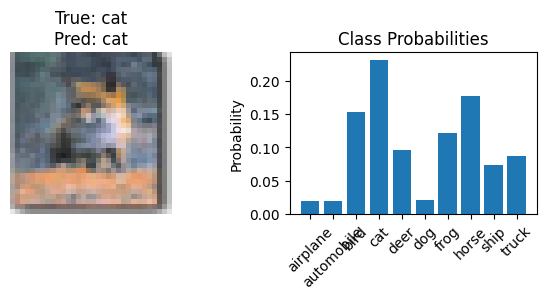

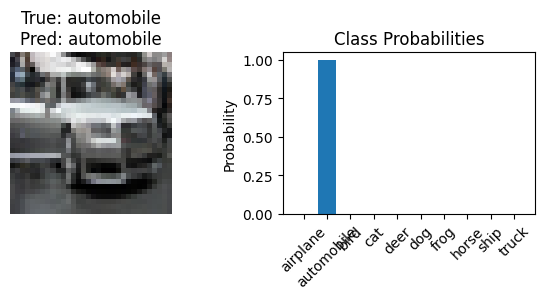

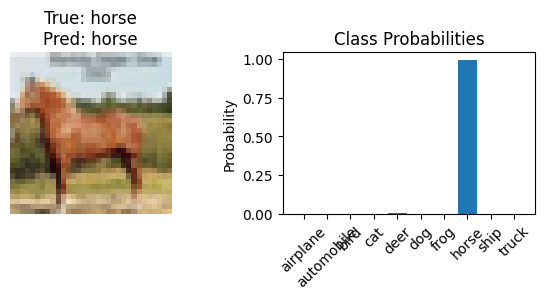

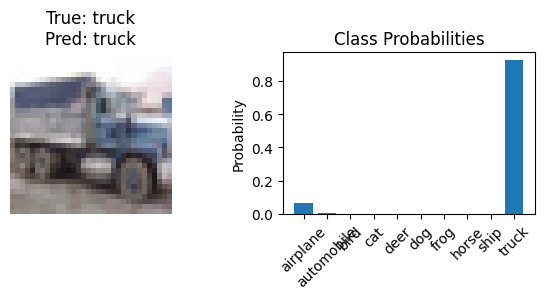

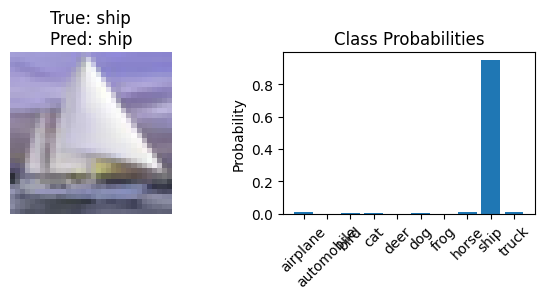

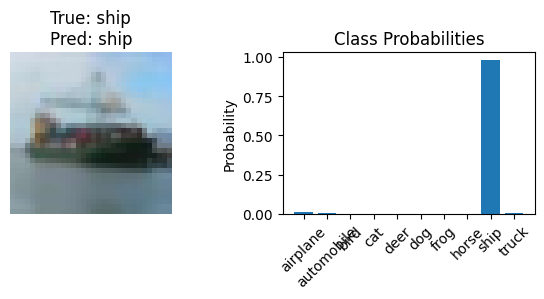

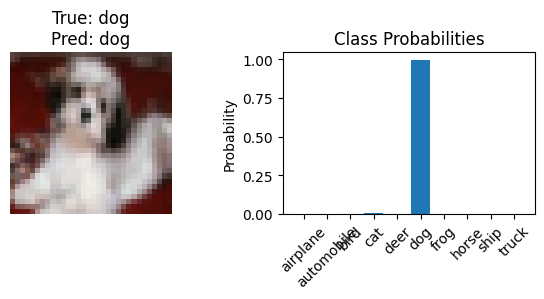

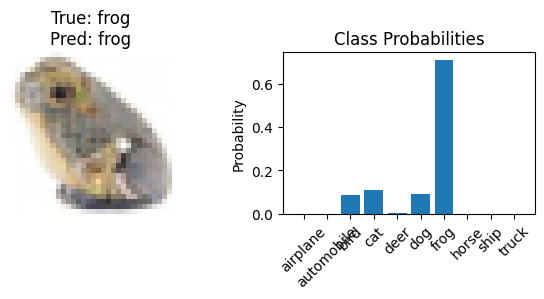

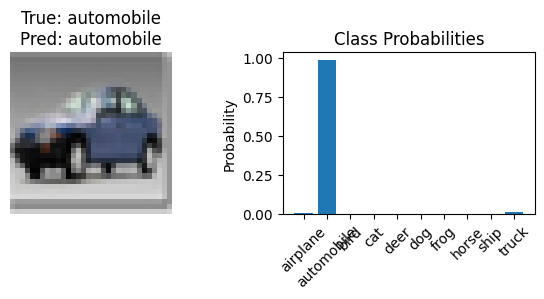

In [47]:
# Class names for CIFAR-10
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Evaluate model
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert one-hot to class index
y_true_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred_prob, axis=1)

# Number of examples to show
num_examples = 10

# Pick random samples
indices = np.random.choice(len(X_test), num_examples, replace=False)

for i, idx in enumerate(indices):
    plt.figure(figsize=(6,3))

    # Show image
    plt.subplot(1,2,1)
    plt.imshow(X_test[idx])
    plt.axis('off')
    plt.title(f"True: {class_names[y_true_class[idx]]}\n"
              f"Pred: {class_names[y_pred_class[idx]]}")

    # Show probability distribution
    plt.subplot(1,2,2)
    plt.bar(range(10), y_pred_prob[idx])
    plt.xticks(range(10), class_names, rotation=45)
    plt.ylabel("Probability")
    plt.title("Class Probabilities")

    plt.tight_layout()
    plt.show()

Final test accuracy is 74,45%. This is not quite as good as the goal of 75-80%, but still acceptable. The model is able to predict most of the images correctly, but there is still room for improvement. 